# Digital Signal Processing - Take Home Assignment

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- CONSTANTS ---
FS = 1000 # Sampling Frequency (Hz)
DURATION = 1.0 # Duration in seconds
N = int(FS * DURATION) # Number of samples
t = np.linspace(0, DURATION, N, endpoint=False)

# --- SIGNAL GENERATION ---
# 1. Sine wave + White Noise for Convolution
clean_signal = np.sin(2 * np.pi * 50 * t)
noise = 0.5 * np.random.normal(size=N)
x_conv = clean_signal + noise

# 2. Composite Signal for DFT (60Hz and 120Hz) + White Noise
x_dft = np.sin(2 * np.pi * 60 * t) + 0.5 * np.sin(2 * np.pi * 120 * t) + 0.5 * np.random.normal(size=N)

In [19]:
def manual_convolution(x, h):
    """
    Implements the Input Side Algorithm.
    x: input signal
    h: impulse response
    """
    Nx = len(x)
    Nh = len(h)
    
    Ny = Nx + Nh - 1
    
    y = np.zeros(Ny)
    
    for n in range(Nx):
        for m in range(Nh):
            y[n + m] += x[n] * h[m]
    
    return y

In [20]:
def calculate_dft(x):
    """
    Implements the DFT via correlation.
    Returns: Magnitude Spectrum
    """
    N = len(x)
    
    ReX = np.zeros(N)
    ImX = np.zeros(N)
    
    for k in range(N):
        for i in range(N):
            angle = 2 * np.pi * k * i / N
            ReX[k] += x[i] * np.cos(angle)
            ImX[k] -= x[i] * np.sin(angle)
    
    Mag = np.sqrt(ReX**2 + ImX**2)
    
    return Mag

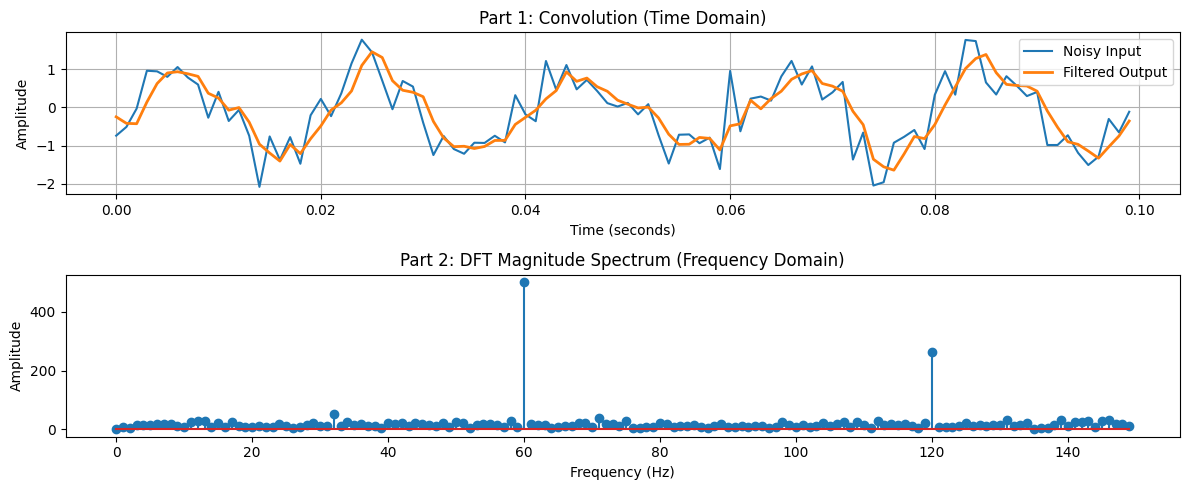

In [21]:
def plot_results():
    # Placeholder for Moving Average Filter kernel
    h = np.ones(3) / 3 
    
    # Convolution Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(t[:100], x_conv[:100], label="Noisy Input")
    y_filtered = manual_convolution(x_conv, h) 
    plt.plot(t[:100], y_filtered[:100], label="Filtered Output", linewidth=2)
    plt.title("Part 1: Convolution (Time Domain)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    
    # DFT Plot
    plt.subplot(2, 1, 2)
    mag_spectrum = calculate_dft(x_dft)
    freq_axis = np.arange(len(mag_spectrum)) * (FS / N)
    plt.stem(freq_axis[:150], mag_spectrum[:150]) 
    plt.title("Part 2: DFT Magnitude Spectrum (Frequency Domain)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_results()